# Titanic Survival Prediction — Gradient Boosting

## 1. Imports

In [310]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
)
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, log_loss
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 2. Load data

In [311]:
df = pd.read_csv("train.csv", delimiter=";")
print(df.shape)
df.head()

(900, 13)


,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [312]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   900 non-null    int64  
 1   PassengerId  900 non-null    int64  
 2   Survived     900 non-null    int64  
 3   Pclass       900 non-null    int64  
 4   Name         900 non-null    str    
 5   Sex          900 non-null    str    
 6   Age          723 non-null    float64
 7   SibSp        900 non-null    int64  
 8   Parch        900 non-null    int64  
 9   Ticket       900 non-null    str    
 10  Fare         900 non-null    float64
 11  Cabin        205 non-null    str    
 12  Embarked     898 non-null    str    
dtypes: float64(2), int64(6), str(5)
memory usage: 91.5 KB


Unnamed: 0       0
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          695
Embarked         2
dtype: int64

## 3. Feature engineering

In [313]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.drop(columns=["PassengerId", "Name", "Ticket", "Embarked", "Cabin"])
    df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                 errors="ignore")
    return df


data = engineer(df)
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [314]:
X = data.drop(columns=["Survived"])
y = data["Survived"]
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


## 4. Preprocessing + model pipeline

In [315]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
categorical_features = ["Sex"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

model = Pipeline([
    ("prep", preprocess),
    ("clf", GradientBoostingClassifier(
        learning_rate=0.05,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        random_state=RANDOM_STATE,
    )),
])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

## 5. Cross-validation

Expect roughly **0.82 – 0.84** accuracy.

In [316]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print(f"CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")
scores

CV accuracy: 0.832 +/- 0.019


array([0.85555556, 0.8       , 0.82777778, 0.84444444, 0.83333333])

## 6. Hyperparameter tuning (optional)

In [317]:
param_grid = {
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_leaf_nodes": [15, 31, 63],
    "clf__min_samples_leaf": [10, 20, 30],
}

search = GridSearchCV(model, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
search.fit(X, y)
print(search.best_params_)
print(f"best ROC AUC: {search.best_score_:.3f}")
model = search.best_estimator_

{'clf__learning_rate': 0.05, 'clf__max_leaf_nodes': 15, 'clf__min_samples_leaf': 30}
best ROC AUC: 0.873


## 7. Fit final model and evaluate

ROC AUC shows how good a model is, nearer to 1.0 is better

              precision    recall  f1-score   support

           0       0.79      0.91      0.84       278
           1       0.81      0.60      0.69       172

    accuracy                           0.79       450
   macro avg       0.80      0.76      0.77       450
weighted avg       0.80      0.79      0.79       450

ROC AUC: 0.844


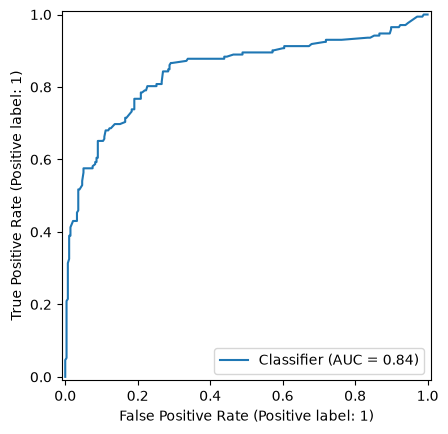

In [318]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=RANDOM_STATE
)

model.fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]

print(classification_report(y_te, model.predict(X_te)))
print("ROC AUC:", round(roc_auc_score(y_te, proba), 3))

RocCurveDisplay.from_predictions(y_te, proba)
plt.show()

## 8. Visualizing the gradient boosting process

Gradient boosting builds an additive ensemble of shallow trees, where each new tree is fit to correct the errors of the ensemble so far. The plots below make that process visible: how the loss falls as more trees are added (and whether the model starts overfitting), and what one individual tree inside the ensemble actually looks like.

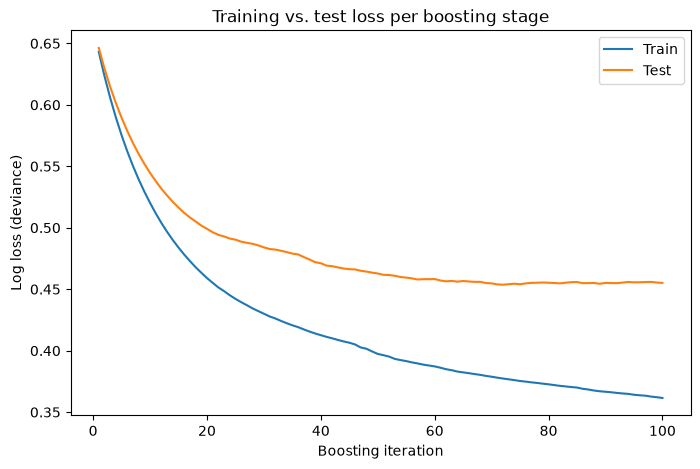

Best iteration on test loss: 72 / 100


In [319]:
clf = model.named_steps["clf"]
prep = model.named_steps["prep"]

X_tr_enc = prep.transform(X_tr)
X_te_enc = prep.transform(X_te)

n_estimators = clf.n_estimators
train_deviance = np.array([
    log_loss(y_tr, proba[:, 1]) for proba in clf.staged_predict_proba(X_tr_enc)
])
test_deviance = np.array([
    log_loss(y_te, proba[:, 1]) for proba in clf.staged_predict_proba(X_te_enc)
])

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, n_estimators + 1), train_deviance, label="Train")
plt.plot(np.arange(1, n_estimators + 1), test_deviance, label="Test")
plt.xlabel("Boosting iteration")
plt.ylabel("Log loss (deviance)")
plt.title("Training vs. test loss per boosting stage")
plt.legend()
plt.show()

print(f"Best iteration on test loss: {test_deviance.argmin() + 1} / {n_estimators}")

### A single tree from the ensemble

Each boosting stage adds one small regression tree that predicts the *residual* error of the ensemble so far. Here's the very first one.

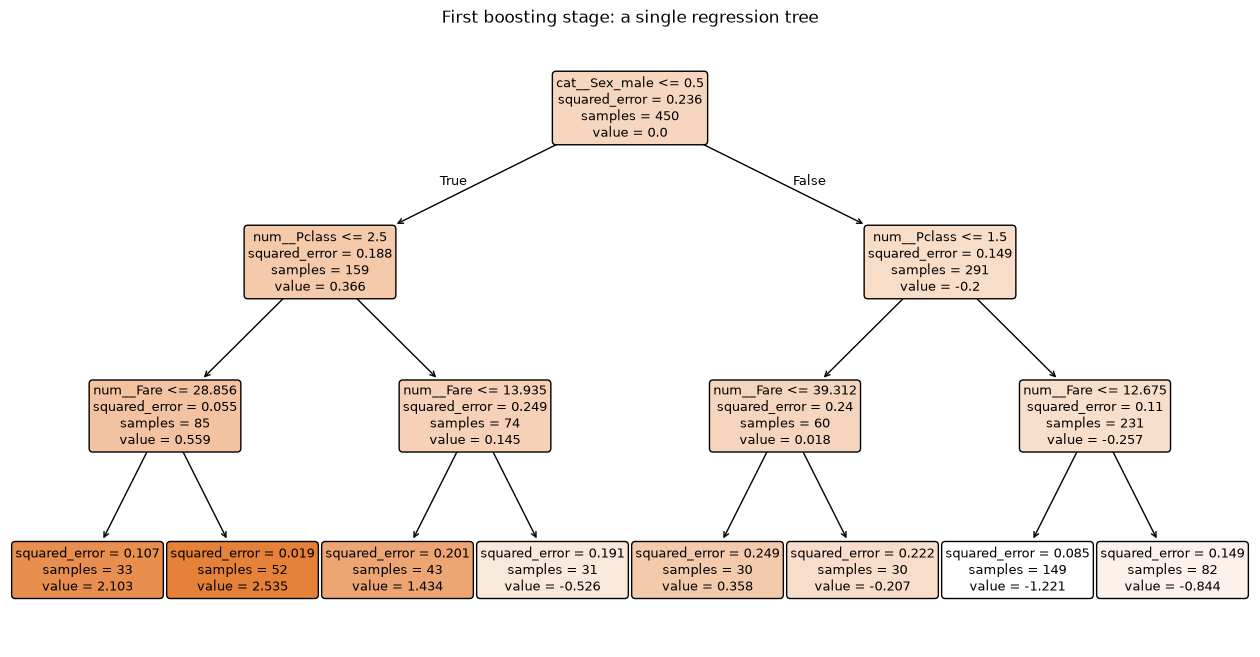

In [320]:
feature_names = prep.get_feature_names_out()

plt.figure(figsize=(16, 8))
plot_tree(
    clf.estimators_[0, 0],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("First boosting stage: a single regression tree")
plt.show()

## 9. Feature importance (permutation)

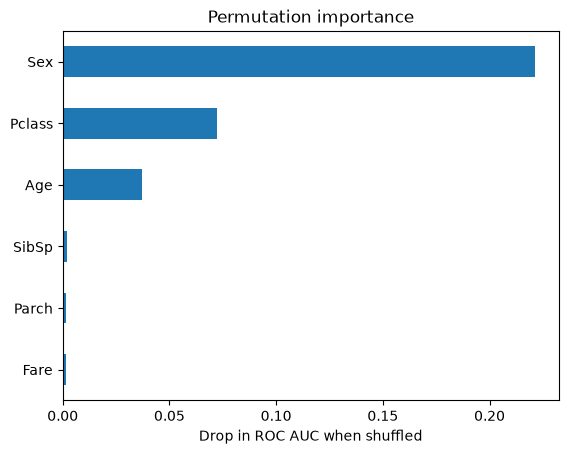

Sex       0.221340
Pclass    0.072352
Age       0.037046
SibSp     0.002167
Parch     0.001684
Fare      0.001622
dtype: float64

In [321]:
perm = permutation_importance(
    model, X_te, y_te, n_repeats=20, random_state=RANDOM_STATE, scoring="roc_auc"
)
importances = (
    pd.Series(perm.importances_mean, index=X.columns)
    .sort_values(ascending=True)
)
importances.plot.barh()
plt.xlabel("Drop in ROC AUC when shuffled")
plt.title("Permutation importance")
plt.show()
importances.sort_values(ascending=False)

## 10. Predict the survival probability of any person

Build a one-row frame with the **raw** columns, run it through `engineer()`, then the pipeline.

In [322]:
def predict_person(pipeline, **fields) -> float:
    raw = pd.DataFrame([{
        "PassengerId": 0, "Pclass": 3,
        "Name": "Doe, Mr. John", "Sex": "male", "Age": 30.0,
        "SibSp": 0, "Parch": 0, "Ticket": "XXX", "Fare": 8.05,
        "Cabin": np.nan, "Embarked": "S",
        **fields,
    }])
    person = engineer(raw)
    return float(pipeline.predict_proba(person)[:, 1][0])


p1 = predict_person(
    model, Sex="female", Age=23, Pclass=1, SibSp=2, Parch=3, Fare=100.0, Cabin="C85"
)
print(f"This person has a survival chance of {p1:.1%}.")

This person has a survival chance of 85.0%.
